# New vs Training Patient Similarity
Analyze how similar new patients are to the training cohort

In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import warnings
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import sys

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

sys.path.append(str(Path().resolve().parent))
from app.patient_encoding import load_and_encode_patient
from data_exploration.umap_embedding import get_umap_embedding

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Load Training Data & Models

In [2]:
# Load training data
features_dir = "../features"
df_train = get_umap_embedding(features_dir, umap_min_dist=0.1, umap_n_neighbors=15)

# Load models
preprocessor = joblib.load("../models/preprocessor.pkl")
with open("../models/feature_order.json") as f:
    feature_order = json.load(f)

# Encode training data
X_train = df_train[feature_order].copy()
X_train_encoded = preprocessor.transform(X_train)

print(f"✓ Loaded {len(df_train)} training patients")
print(f"✓ Total features: {len(feature_order)}")

✓ Loaded 626 training patients
✓ Total features: 79


## 2. Load New Patients

In [3]:
# Load new patients from data directory
patient_ids = ['002', '005', '006', '008', '010', '011', '013', '015']
new_patients = {}

print("Loading new patients...\n")
for patient_id in patient_ids:
    patient_path = f"../data/{patient_id}/raw"
    try:
        df_patient = load_and_encode_patient(patient_path, patient_id=patient_id)
        new_patients[patient_id] = df_patient
        print(f"✓ Loaded patient {patient_id}")
    except Exception as e:
        print(f"✗ Failed to load patient {patient_id}: {e}")

print(f"\n✓ Successfully loaded {len(new_patients)} new patients")

Loading new patients...

['icd_codes_002.txt']
  patient_id   icd_code
0        002  R048 C320
  year_of_initial_diagnosis age_at_initial_diagnosis   sex smoking_status  \
0                      None                       80  male         former   

  primarily_metastasis survival_status survival_status_with_cause  \
0                  yes            None                       None   

  days_to_last_information first_treatment_intent first_treatment_modality  \
0                     None                   None                     None   

   ... adjuvant_radiotherapy adjuvant_radiotherapy_modality  \
0  ...                  None                           None   

  adjuvant_systemic_therapy adjuvant_systemic_therapy_modality  \
0                      None                               None   

  adjuvant_radiochemotherapy recurrence days_to_recurrence  \
0                       None       None               None   

  days_to_metastasis_1 days_to_progress_1 patient_id  
0             

## 3. Compute Similarity to Training Cohort

In [4]:
# Compute similarity of each new patient to all training patients
results = []
all_similarities = {}

print("Computing similarities...\n")
print("="*90)

for patient_id, df_patient in new_patients.items():
    # Encode new patient
    X_patient = df_patient[feature_order].copy()
    X_patient_encoded = preprocessor.transform(X_patient)
    
    # Compute similarity to all training patients
    similarities = cosine_similarity(X_patient_encoded, X_train_encoded)[0]
    all_similarities[patient_id] = similarities
    
    # Get top 5 similar training patients
    top_idx = similarities.argsort()[::-1][:5]
    top_ids = [df_train.iloc[i]['patient_id'] for i in top_idx]
    top_scores = similarities[top_idx]
    
    # Statistics
    mean_sim = np.mean(similarities)
    max_sim = np.max(similarities)
    min_sim = np.min(similarities)
    
    print(f"\nPatient {patient_id}:")
    print(f"  Top 5 similar:  {' → '.join(str(int(id)) for id in top_ids)}")
    print(f"  Scores:         {[f'{s:.4f}' for s in top_scores]}")
    print(f"  Cohort stats:   Mean={mean_sim:.4f}, Max={max_sim:.4f}, Min={min_sim:.4f}")
    
    results.append({
        'Patient': patient_id,
        'Most_Similar': int(top_ids[0]),
        'Top5_Avg_Score': top_scores.mean(),
        'Cohort_Mean': mean_sim,
        'Cohort_Max': max_sim,
        'Cohort_Min': min_sim
    })

print("\n" + "="*90)
results_df = pd.DataFrame(results)
print("\nSUMMARY TABLE:")
print(results_df.to_string(index=False))

Computing similarities...


Patient 002:
  Top 5 similar:  709 → 192 → 186 → 674 → 9
  Scores:         ['0.6514', '0.6481', '0.6456', '0.6180', '0.6131']
  Cohort stats:   Mean=0.1151, Max=0.6514, Min=-0.3644

Patient 005:
  Top 5 similar:  202 → 480 → 41 → 719 → 242
  Scores:         ['0.6810', '0.6783', '0.6719', '0.6419', '0.6342']
  Cohort stats:   Mean=0.1668, Max=0.6810, Min=-0.3476

Patient 006:
  Top 5 similar:  573 → 284 → 724 → 167 → 7
  Scores:         ['0.6716', '0.6507', '0.6293', '0.5905', '0.5842']
  Cohort stats:   Mean=0.0830, Max=0.6716, Min=-0.3728

Patient 008:
  Top 5 similar:  270 → 684 → 416 → 220 → 113
  Scores:         ['0.6258', '0.5800', '0.5791', '0.5786', '0.5777']
  Cohort stats:   Mean=0.1022, Max=0.6258, Min=-0.3800

Patient 010:
  Top 5 similar:  318 → 669 → 750 → 145 → 202
  Scores:         ['0.6107', '0.5950', '0.5704', '0.5612', '0.5604']
  Cohort stats:   Mean=0.1408, Max=0.6107, Min=-0.3979

Patient 011:
  Top 5 similar:  723 → 481 → 663 → 587 → 87

## 4. Visualizations

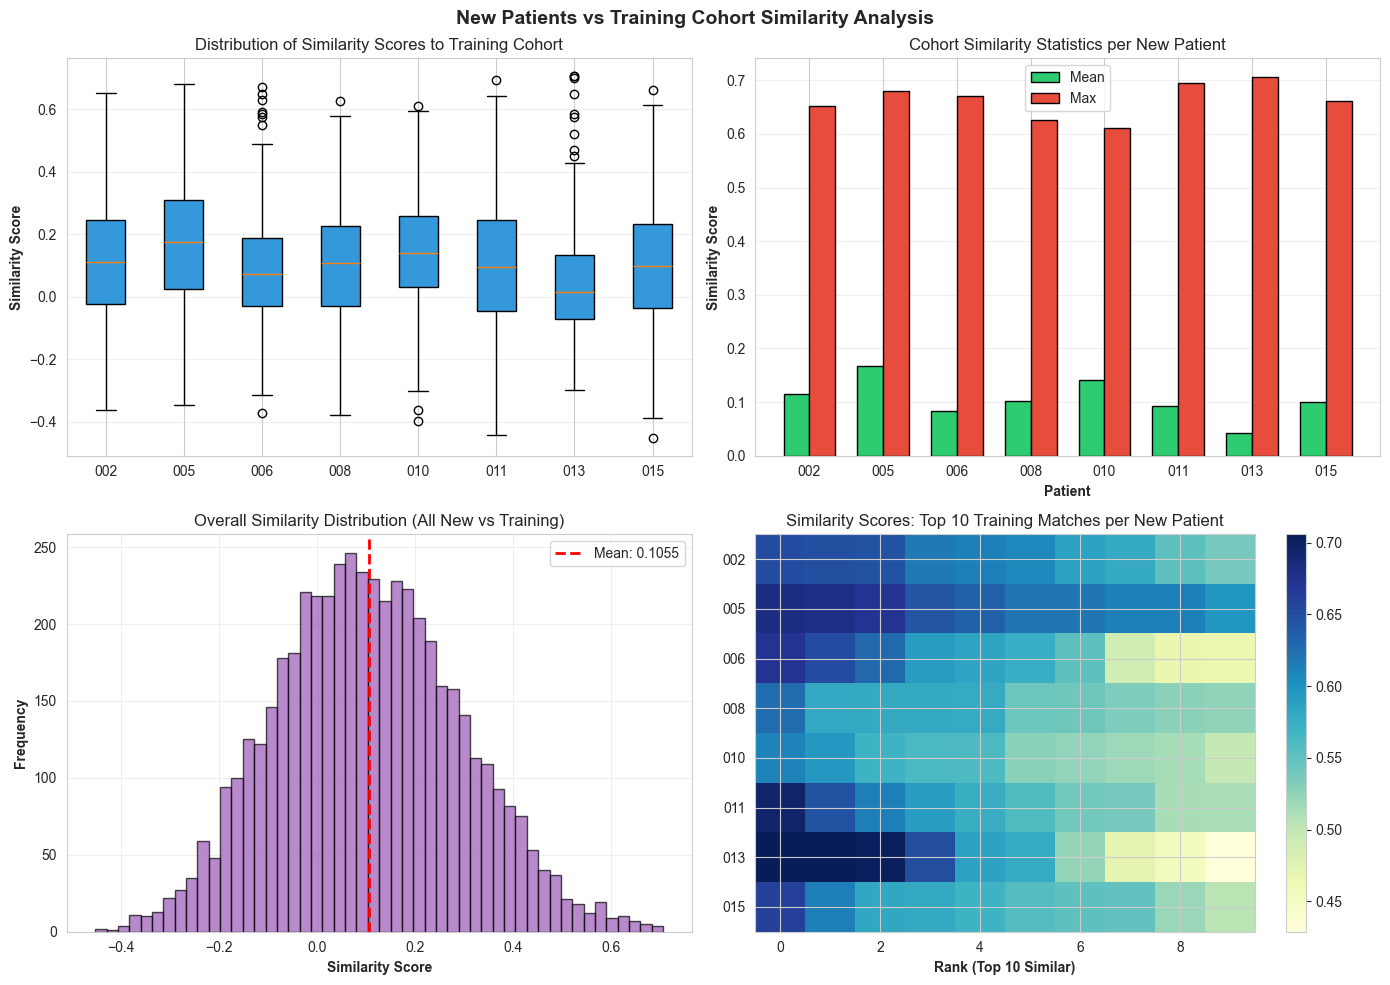

✓ Visualizations complete


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('New Patients vs Training Cohort Similarity Analysis', fontsize=14, fontweight='bold')

# Plot 1: Box plot of similarity distributions
ax1 = axes[0, 0]
patient_ids_list = list(all_similarities.keys())
sim_data = [all_similarities[pid] for pid in patient_ids_list]

bp = ax1.boxplot(sim_data, labels=patient_ids_list, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#3498db')
ax1.set_ylabel('Similarity Score', fontweight='bold')
ax1.set_title('Distribution of Similarity Scores to Training Cohort')
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Mean and max similarities per patient
ax2 = axes[0, 1]
x = np.arange(len(results_df))
width = 0.35

ax2.bar(x - width/2, results_df['Cohort_Mean'], width, label='Mean', color='#2ecc71', edgecolor='black')
ax2.bar(x + width/2, results_df['Cohort_Max'], width, label='Max', color='#e74c3c', edgecolor='black')
ax2.set_xlabel('Patient', fontweight='bold')
ax2.set_ylabel('Similarity Score', fontweight='bold')
ax2.set_title('Cohort Similarity Statistics per New Patient')
ax2.set_xticks(x)
ax2.set_xticklabels(results_df['Patient'])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Histogram of all similarities
ax3 = axes[1, 0]
all_sims_flat = np.concatenate(list(all_similarities.values()))
ax3.hist(all_sims_flat, bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
ax3.axvline(np.mean(all_sims_flat), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(all_sims_flat):.4f}')
ax3.set_xlabel('Similarity Score', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.set_title('Overall Similarity Distribution (All New vs Training)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Heatmap of top similarities
ax4 = axes[1, 1]
heatmap_data = []
for pid in patient_ids_list:
    similarities = all_similarities[pid]
    # Show top 10
    top_10_idx = similarities.argsort()[::-1][:10]
    heatmap_data.append(similarities[top_10_idx])

heatmap_array = np.array(heatmap_data)
im = ax4.imshow(heatmap_array, cmap='YlGnBu', aspect='auto')
ax4.set_yticks(range(len(patient_ids_list)))
ax4.set_yticklabels(patient_ids_list)
ax4.set_xlabel('Rank (Top 10 Similar)', fontweight='bold')
ax4.set_title('Similarity Scores: Top 10 Training Matches per New Patient')
plt.colorbar(im, ax=ax4)

plt.tight_layout()
plt.show()

print("✓ Visualizations complete")

## Summary

### What This Notebook Shows
- Compares each **new patient** to the entire **training cohort**
- Identifies the most similar training patients for each new patient
- Analyzes how well new patients fit into the training distribution

### Key Metrics
- **Most_Similar**: Patient ID of nearest neighbor in training data
- **Top5_Avg_Score**: Average similarity of the 5 most similar training patients
- **Cohort_Mean**: Average similarity across all training patients
- **Cohort_Max**: Maximum similarity (best match)
- **Cohort_Min**: Minimum similarity (worst match)

### Interpretation
- **High cohort_mean (>0.5)**: New patient is similar overall to training cohort
- **High cohort_max (>0.8)**: Strong match exists in training data
- **Low cohort_mean (<0.3)**: New patient is an outlier or distinct from training
- **Wide range (max-min)**: Cohort is diverse in relation to new patient

### Use Cases
- Identify if new patients are within expected parameter ranges
- Find best historical matches for clinical decision support
- Detect outliers or unusual patient profiles